# Modelo de movilidad y emisiones del AMB
Este notebook organiza en un flujo único la preparación del parque automotor, la generación de archivos de entrada para COPERT, la proyección 2025–2030 y la evaluación de escenarios de penetración eléctrica.

**Orden de ejecución:** cada bloque depende únicamente de variables creadas en bloques anteriores. La tabla `df_estimacion` es la fuente maestra del parque automotor y `proyeccion` es la fuente maestra de la proyección 2025–2030.


## 1. Configuración e importación de librerías

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

BASE = Path("/content/drive/MyDrive/ProyectoMo")
DATA_RESULT = BASE / "Data_Simulacion_Copert" / "Data_Result"
BD_ANDEMOS = BASE / "BD_Andemos"
OUT = DATA_RESULT / "Graficas_Capitulo_5"
OUT.mkdir(parents=True, exist_ok=True)

YEARS_HIST = list(range(2018, 2026))
YEARS_COPERT = list(range(2020, 2026))
YEARS_PROJECTION = list(range(2025, 2031))
TARGET_CLASSES = ["AUTOMÓVIL", "CAMIONETA", "BUS", "BUSETA", "MICRO BUS", "MOTOCICLETA"]
PLOT_DPI = 300

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


In [2]:
from google.colab import drive
import os
import shutil

mount_point = "/content/drive"

# Ensure the mount point is clean before attempting to mount
# This addresses the 'Mountpoint must not already contain files' error.
if os.path.exists(mount_point) and os.path.isdir(mount_point) and os.listdir(mount_point):
    print(f"Clearing contents of {mount_point} before mounting...")
    for item in os.listdir(mount_point):
        item_path = os.path.join(mount_point, item)
        try:
            if os.path.isfile(item_path) or os.path.islink(item_path):
                os.remove(item_path)
            elif os.path.isdir(item_path):
                shutil.rmtree(item_path)
        except Exception as e:
            print(f"Error clearing {item_path}: {e}")

drive.mount(mount_point, force_remount=True)

Clearing contents of /content/drive before mounting...
Mounted at /content/drive


## 2. Parque automotor del AMB

La serie 2018–2022 se conserva con los valores históricos utilizados en el notebook original. Para 2023–2025, el parque se estima a partir de la base `DataBase.xlsx`, agregando las nuevas matrículas registradas en los cuatro municipios del AMB a partir del stock del año anterior.

In [3]:
path_excel = BASE / "DataBase.xlsx"

data_hist = {
    "CLASE": [
        "AUTOMÓVIL", "BUS", "BUSETA", "CAMIÓN", "CAMIONETA", "CAMPERO", "MICRO BUS",
        "TRACTO CAMIÓN", "VOLQUETA", "MOTOCICLETA", "MOTOCARRO", "MOTO TRICICLO",
        "CICLOMOTOR", "CUATRIMOTO", "CUADRICICLO", "SEMIRREMOLQUE", "REMOLQUE"
    ],
    "2018": [160411, 4514, 4045, 17405, 60173, 23883, 3856, 5983, 3047, 410651, 1009, 28, 0, 223, 0, 486, 7280],
    "2019": [164916, 4972, 4924, 17320, 62819, 23759, 4653, 6207, 3095, 445045, 1151, 8, 73, 223, 11, 6453, 1414],
    "2020": [161884, 3583, 3579, 16665, 64906, 23498, 3431, 5688, 3076, 462379, 1348, 9, 125, 233, 11, 6863, 1455],
    "2021": [165310, 3564, 3549, 17332, 68036, 23870, 3431, 5916, 3197, 493521, 1728, 10, 154, 238, 20, 7348, 1600],
    "2022": [170264, 3837, 3570, 18449, 70929, 24464, 3609, 6583, 3311, 528835, 2213, 13, 196, 251, 25, 9115, 1868]
}
df_stock = pd.DataFrame(data_hist).set_index("CLASE")

mapping_nombres = {
    "AUTOMOVIL": "AUTOMÓVIL", "BUS": "BUS", "BUSETA": "BUSETA",
    "CAMION": "CAMIÓN", "CAMIÓN": "CAMIÓN", "CAMIONETA": "CAMIONETA",
    "CAMPERO": "CAMPERO", "MICROBUS": "MICRO BUS", "TRACTOCAMION": "TRACTO CAMIÓN",
    "VOLQUETA": "VOLQUETA", "MOTOCICLETA": "MOTOCICLETA", "MOTOCARRO": "MOTOCARRO",
    "MOTOTRICICLO": "MOTO TRICICLO", "CICLOMOTOR": "CICLOMOTOR",
    "CUATRIMOTO": "CUATRIMOTO", "CUADRICICLO": "CUADRICICLO",
    "SEMIREMOLQUE": "SEMIRREMOLQUE", "REMOLQUE": "REMOLQUE"
}

df_db = pd.read_excel(path_excel)
df_db["CLASE_CORREGIDA"] = df_db["NOMBRE_DE_LA_CLASE"].map(mapping_nombres)

amb = ["BUCARAMANGA", "FLORIDABLANCA", "GIRON", "PIEDECUESTA"]
df_amb = df_db[df_db["NOMBRE_MUNICIPIO"].isin(amb)].copy()
matriculas_anuales = df_amb.groupby(["FECHA DE REGISTRO", "CLASE_CORREGIDA"])["CANTIDAD"].sum().unstack(fill_value=0)

for year in [2023, 2024, 2025]:
    stock_anterior = df_stock[str(year - 1)]
    nuevos = matriculas_anuales.loc[year] if year in matriculas_anuales.index else pd.Series(dtype=float)
    df_stock[str(year)] = stock_anterior + nuevos.reindex(df_stock.index, fill_value=0)

df_estimacion = df_stock.round(0).astype(int)
df_estimacion.to_csv(DATA_RESULT / "Parque_Automotor_Consolidado_AMB.csv")

display(df_estimacion)


,2018,2019,2020,2021,2022,2023,2024,2025
CLASE,,,,,,,,
AUTOMÓVIL,160411,164916,161884,165310,170264,172158,174521,177506
BUS,4514,4972,3583,3564,3837,3884,3963,4020
BUSETA,4045,4924,3579,3549,3570,3576,3581,3592
CAMIÓN,17405,17320,16665,17332,18449,18856,19237,19832
CAMIONETA,60173,62819,64906,68036,70929,73583,77676,83904
CAMPERO,23883,23759,23498,23870,24464,24764,25137,25716
MICRO BUS,3856,4653,3431,3431,3609,3622,3640,3669
TRACTO CAMIÓN,5983,6207,5688,5916,6583,6733,6839,7057
VOLQUETA,3047,3095,3076,3197,3311,3343,3360,3412


In [4]:
YEARS_HIST_COLS = [str(year) for year in YEARS_HIST]

parque_objetivo = df_estimacion.loc[TARGET_CLASSES, YEARS_HIST_COLS].copy()
parque_objetivo["Total 2025"] = parque_objetivo["2025"]

print(f"Total de categorías objetivo en 2025: {parque_objetivo['2025'].sum():,} vehículos")
display(parque_objetivo)

Total de categorías objetivo en 2025: 910,513 vehículos


,2018,2019,2020,2021,2022,2023,2024,2025,Total 2025
CLASE,,,,,,,,,
AUTOMÓVIL,160411,164916,161884,165310,170264,172158,174521,177506,177506
CAMIONETA,60173,62819,64906,68036,70929,73583,77676,83904,83904
BUS,4514,4972,3583,3564,3837,3884,3963,4020,4020
BUSETA,4045,4924,3579,3549,3570,3576,3581,3592,3592
MICRO BUS,3856,4653,3431,3431,3609,3622,3640,3669,3669
MOTOCICLETA,410651,445045,462379,493521,528835,556080,590377,637822,637822


## 3. Parámetros COPERT: categorías, combustible, actividad y supervivencia

In [5]:
params = {
    "AUTOMÓVIL": {"k": 2.8, "lam": 20},
    "CAMIONETA": {"k": 2.8, "lam": 22},
    "BUS": {"k": 3.5, "lam": 25},
    "BUSETA": {"k": 3.5, "lam": 25},
    "MICRO BUS": {"k": 3.0, "lam": 18},
    "MOTOCICLETA": {"k": 2.0, "lam": 12}
}

mapeo_segmentos = {
    ("Passenger Cars", "Medium"): "AUTOMÓVIL",
    ("Passenger Cars", "Large"): "CAMIONETA",
    ("Buses", "Urban Buses Standard 15 - 18 t"): "BUS",
    ("Buses", "Urban Buses Midi <=15 t"): "BUSETA",
    ("Buses", "Coaches Midi <=15 t"): "MICRO BUS",
    ("L-Category", "Motorcycles 4-stroke <250 cm³"): "MOTOCICLETA"
}

mapeo_categoria = {
    "AUTOMÓVIL": "Passenger Cars",
    "CAMIONETA": "Passenger Cars",
    "BUS": "Buses",
    "BUSETA": "Buses",
    "MICRO BUS": "Buses",
    "MOTOCICLETA": "L-Category"
}

fuel_map = {
    "Gasolina": "Petrol",
    "Diesel": "Diesel",
    "Electrico": "Battery electric",
    "Hibrido No Enchufable": "Petrol Hybrid",
    "Hibrido Enchufable": "Petrol PHEV",
    "Gas Convertido": "CNG",
    "Gnv": "CNG"
}

activity_map = {
    "Passenger Cars": 12500,
    "Buses": 48000,
    "L-Category": 9500
}

archivos_tech = {
    "AUTOMÓVIL": BD_ANDEMOS / "AUTOMOVIL.csv",
    "BUS": BD_ANDEMOS / "BUS.csv",
    "BUSETA": BD_ANDEMOS / "BUSETA.csv",
    "MICRO BUS": BD_ANDEMOS / "MICROBUS.csv",
    "CAMIONETA": BD_ANDEMOS / "CAMIONETA.csv"
}


In [6]:
def survival_function(age, k, lam):
    return np.exp(-(age / lam) ** k)

def get_euro_distribution(category, sim_year, k, lam):
    ages = np.arange(0, 41)
    weights = survival_function(ages, k, lam)
    weights = weights / weights.sum()
    distribution = {}
    is_hdv = category == "Buses"

    for age, weight in zip(ages, weights):
        birth_year = sim_year - age
        if birth_year >= 2023:
            standard = "Euro VI A/B/C" if is_hdv else "Euro 6 a/b/c"
        elif birth_year >= 2015:
            standard = "Euro V" if is_hdv and birth_year >= 2019 else "Euro IV" if is_hdv else "Euro 5" if birth_year >= 2019 else "Euro 4"
        elif birth_year >= 2001:
            standard = "Euro III" if is_hdv and birth_year >= 2009 else "Euro II" if is_hdv else "Euro 3" if birth_year >= 2009 else "Euro 2"
        else:
            standard = "Euro I" if is_hdv and birth_year >= 1996 else "Conventional" if is_hdv else "Euro 1" if birth_year >= 1996 else "Conventional"
        distribution[standard] = distribution.get(standard, 0) + weight
    return distribution

tech_weights = {}
for clase, path in archivos_tech.items():
    if path.exists():
        df_t = pd.read_csv(path)
        df_t.columns = [str(c).strip() for c in df_t.columns]
        required = {"TIPO TECNOLOGIA", "Total"}
        if required.issubset(df_t.columns):
            total = df_t["Total"].sum()
            if total > 0:
                weights = {}
                for _, row in df_t.iterrows():
                    fuel = fuel_map.get(row["TIPO TECNOLOGIA"], "Petrol")
                    weights[fuel] = weights.get(fuel, 0) + row["Total"] / total
                tech_weights[clase] = weights

for clase in TARGET_CLASSES:
    tech_weights.setdefault(clase, {"Petrol": 1.0})

display(pd.DataFrame(tech_weights).fillna(0))


,AUTOMÓVIL,BUS,BUSETA,MICRO BUS,CAMIONETA,MOTOCICLETA
CNG,0.000034,0.001029,0.0,0.000000,0.001169,0.0
Diesel,0.000153,0.998971,1.0,0.994273,0.698468,0.0
Petrol PHEV,0.000221,0.000000,0.0,0.000000,0.000000,0.0
Battery electric,0.001397,0.000000,0.0,0.000000,0.000234,0.0
Petrol Hybrid,0.003338,0.000000,0.0,0.000000,0.001169,0.0
Petrol,0.994857,0.000000,0.0,0.005727,0.298959,1.0


## 4. Generación de archivos de entrada para COPERT, 2020–2025

In [7]:
conf_path = BASE / "Stock_Configuration_Colombia.csv"
act_path = BASE / "Stock_&_Activity_Data_Colombia.csv"

conf_tmpl = pd.read_csv(conf_path).loc[:, lambda d: ~d.columns.str.contains("^Unnamed")]
act_tmpl = pd.read_csv(act_path).loc[:, lambda d: ~d.columns.str.contains("^Unnamed")]

for year in YEARS_COPERT:
    df_c = conf_tmpl.copy()
    df_a = act_tmpl.copy()
    df_c["Include"] = False
    df_a[["Stock [n]", "Mean Activity [km]", "Lifetime Cumulative Activity [km]"]] = 0.0

    for (category, segment), clase_local in mapeo_segmentos.items():
        total_stock = int(df_estimacion.loc[clase_local, str(year)])
        euro_dist = get_euro_distribution(category, year, params[clase_local]["k"], params[clase_local]["lam"])
        weights = tech_weights.get(clase_local, {"Petrol": 1.0})
        activity = activity_map[category]

        for fuel, fuel_weight in weights.items():
            for standard, euro_weight in euro_dist.items():
                stock_n = int(round(total_stock * fuel_weight * euro_weight))
                mask = (
                    (df_c["Category"] == category)
                    & (df_c["Fuel"] == fuel)
                    & (df_c["Segment"] == segment)
                    & (df_c["Euro Standard"] == standard)
                )
                if mask.any() and stock_n > 0:
                    df_c.loc[mask, "Include"] = True
                    df_a.loc[mask, ["Stock [n]", "Mean Activity [km]"]] = [stock_n, activity]
                    df_a.loc[mask, "Lifetime Cumulative Activity [km]"] = stock_n * activity * 6

    df_c_final = df_c[df_c["Include"]].copy()
    df_a_final = df_a[df_a["Stock [n]"] > 0].copy()
    df_c_final.to_csv(DATA_RESULT / f"Stock_Configuration_Bucaramanga_{year}.csv", index=False)
    df_a_final.to_csv(DATA_RESULT / f"Stock_&_Activity_Data_Bucaramanga_{year}.csv", index=False)
    print(f"{year}: {len(df_c_final)} configuraciones y {len(df_a_final)} registros activos.")


2020: 31 configuraciones y 31 registros activos.
2021: 31 configuraciones y 31 registros activos.
2022: 31 configuraciones y 31 registros activos.
2023: 37 configuraciones y 37 registros activos.
2024: 37 configuraciones y 37 registros activos.
2025: 37 configuraciones y 37 registros activos.


## 5. Proyección del parque automotor 2025–2030

La proyección utiliza el CAGR observado entre 2022 y 2025 para cada categoría objetivo. No se utiliza una segunda tabla de stock ni valores alternativos: `df_estimacion` es la única fuente de stock.

In [8]:
def calcular_cagr(valor_inicial, valor_final, n_periodos):
    if valor_inicial <= 0 or valor_final < 0:
        return 0.0
    return (valor_final / valor_inicial) ** (1 / n_periodos) - 1

tasas_cagr = {}
for clase in TARGET_CLASSES:
    tasas_cagr[clase] = calcular_cagr(df_estimacion.loc[clase, "2022"], df_estimacion.loc[clase, "2025"], 3)

tasas_cagr_df = pd.DataFrame.from_dict(tasas_cagr, orient="index", columns=["CAGR"])
display(tasas_cagr_df.style.format({"CAGR": "{:.4%}"}))


,CAGR
AUTOMÓVIL,1.3982%
CAMIONETA,5.7596%
BUS,1.5652%
BUSETA,0.2050%
MICRO BUS,0.5511%
MOTOCICLETA,6.4453%


In [9]:
def generar_proyeccion_parque(df_stock_maestro):
    registros = []

    for clase in TARGET_CLASSES:
        stock_2025 = int(df_stock_maestro.loc[clase, "2025"])
        cagr = tasas_cagr[clase]
        weights = tech_weights.get(clase, {"Petrol": 1.0})

        for year in YEARS_PROJECTION:
            total_year = stock_2025 * (1 + cagr) ** (year - 2025)
            for technology, weight in weights.items():
                registros.append({
                    "Año": year,
                    "Vehículo": clase,
                    "Tecnología": technology,
                    "Cantidad": int(round(total_year * weight))
                })

    return pd.DataFrame(registros)

proyeccion = generar_proyeccion_parque(df_estimacion)
proyeccion.to_csv(DATA_RESULT / "proyeccion_parque_automotor_2025_2030.csv", index=False)

parque_anual = proyeccion.groupby("Año", as_index=False)["Cantidad"].sum()
parque_categoria = proyeccion.groupby(["Año", "Vehículo"], as_index=False)["Cantidad"].sum()

display(parque_anual)


,Año,Cantidad
0,2025,910513
1,2026,959028
2,2027,1010506
3,2028,1065132
4,2029,1123114
5,2030,1184655


In [10]:
tabla_proyeccion = proyeccion.pivot_table(index=["Vehículo", "Tecnología"], columns="Año", values="Cantidad", aggfunc="sum", fill_value=0).reset_index()
display(tabla_proyeccion)


Año,Vehículo,Tecnología,2025,2026,2027,2028,2029,2030
0,AUTOMÓVIL,Battery electric,248,251,255,258,262,266
1,AUTOMÓVIL,CNG,6,6,6,6,6,6
2,AUTOMÓVIL,Diesel,27,28,28,28,29,29
3,AUTOMÓVIL,Petrol,176593,179062,181566,184104,186678,189288
4,AUTOMÓVIL,Petrol Hybrid,593,601,609,618,626,635
5,AUTOMÓVIL,Petrol PHEV,39,40,40,41,42,42
6,BUS,CNG,4,4,4,4,4,4
7,BUS,Diesel,4016,4079,4143,4207,4273,4340
8,BUSETA,Diesel,3592,3599,3607,3614,3622,3629
9,CAMIONETA,Battery electric,20,21,22,23,25,26


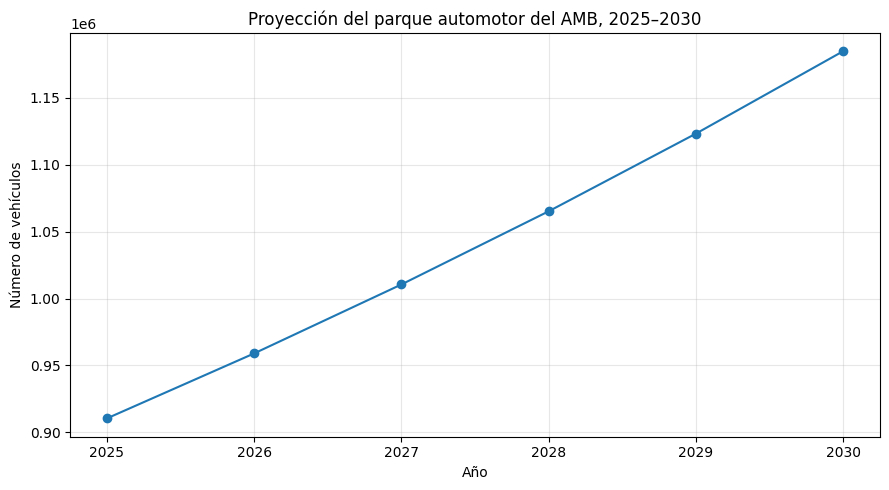

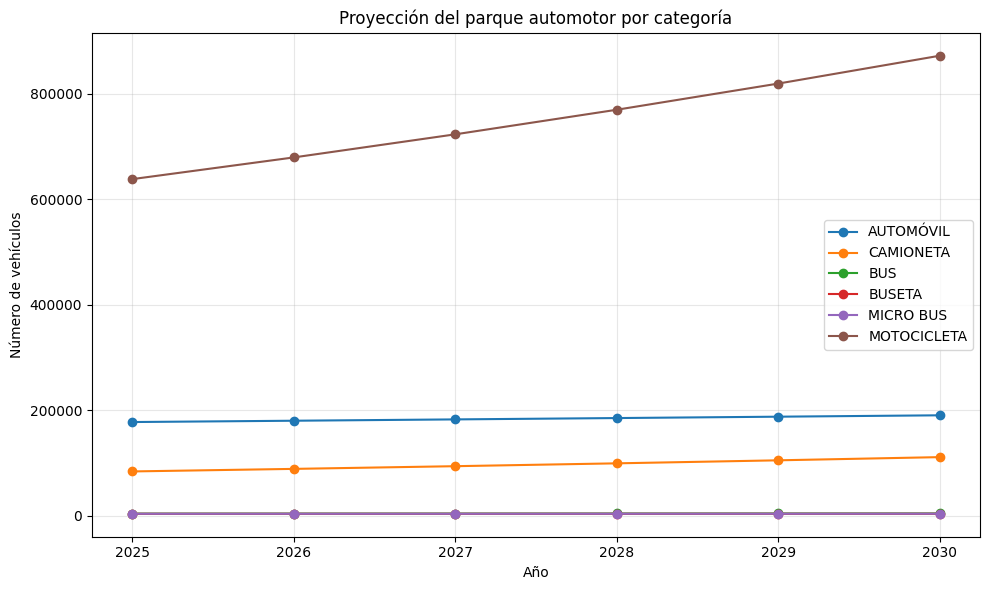

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(parque_anual["Año"], parque_anual["Cantidad"], marker="o")
plt.xlabel("Año")
plt.ylabel("Número de vehículos")
plt.title("Proyección del parque automotor del AMB, 2025–2030")
plt.xticks(YEARS_PROJECTION)
plt.tight_layout()
plt.savefig(OUT / "Proyeccion_Parque_Automotor.png", dpi=PLOT_DPI, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
for clase in TARGET_CLASSES:
    datos = parque_categoria[parque_categoria["Vehículo"] == clase]
    plt.plot(datos["Año"], datos["Cantidad"], marker="o", label=clase)
plt.xlabel("Año")
plt.ylabel("Número de vehículos")
plt.title("Proyección del parque automotor por categoría")
plt.xticks(YEARS_PROJECTION)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "Proyeccion_Parque_por_Categoria.png", dpi=PLOT_DPI, bbox_inches="tight")
plt.show()


In [12]:
pivot_tecnologia = proyeccion.pivot_table(index="Año", columns="Tecnología", values="Cantidad", aggfunc="sum", fill_value=0)
pivot_vehiculo = proyeccion.pivot_table(index="Año", columns="Vehículo", values="Cantidad", aggfunc="sum", fill_value=0)
display(pivot_tecnologia)
display(pivot_vehiculo)


Tecnología,Battery electric,CNG,Diesel,Petrol,Petrol Hybrid,Petrol PHEV
Año,,,,,,
2025,268,108,69887,839520,691,39
2026,272,114,73354,884543,705,40
2027,277,120,77015,932335,719,40
2028,281,126,80883,983067,734,41
2029,287,133,84971,1036932,749,42
2030,292,140,89288,1094128,765,42


Vehículo,AUTOMÓVIL,BUS,BUSETA,CAMIONETA,MICRO BUS,MOTOCICLETA
Año,,,,,,
2025,177506,4020,3592,83904,3669,637822
2026,179988,4083,3599,88738,3689,678931
2027,182504,4147,3607,93848,3709,722691
2028,185055,4211,3614,99252,3730,769270
2029,187643,4277,3622,104970,3750,818852
2030,190266,4344,3629,111015,3772,871629


## 6. Información climática

In [13]:
import requests

def generar_csv_clima(start_year, end_year, lat=7.1194, lon=-73.1227):
    base_url = "https://archive-api.open-meteo.com/v1/archive"
    params_api = {
        "latitude": lat,
        "longitude": lon,
        "start_date": f"{start_year}-01-01",
        "end_date": f"{end_year}-12-31",
        "daily": "temperature_2m_mean,precipitation_sum,et0_fao_evapotranspiration",
        "timezone": "America/Bogota"
    }
    response = requests.get(base_url, params=params_api, timeout=60)
    response.raise_for_status()
    data = response.json()
    return pd.DataFrame(data["daily"])

# Ejemplo de uso:
# clima = generar_csv_clima(2020, 2025)
# clima.to_csv(DATA_RESULT / "clima_AMB_2020_2025.csv", index=False)


## 7. Línea base de emisiones COPERT, 2020–2025

In [14]:
def cargar_emisiones(nombre):
    path = DATA_RESULT / nombre
    if not path.exists():
        raise FileNotFoundError(f"No se encontró: {path}")
    return pd.read_excel(path)

df_co = cargar_emisiones("Emissions_for_All_Years_Colombia_CO.xlsx")
df_co2 = cargar_emisiones("Emissions_for_All_Years_Colombia_CO2.xlsx")
df_pm = cargar_emisiones("Emissions_for_All_Years_Colombia_PM25.xlsx")

def emisiones_anuales(df):
    return df.groupby("Year")["Total"].sum()

linea_base = pd.DataFrame({
    "CO": emisiones_anuales(df_co),
    "CO2": emisiones_anuales(df_co2),
    "PM2.5": emisiones_anuales(df_pm)
})
linea_base.index.name = "Año"

resultados_linea_base = []
for contaminante in linea_base.columns:
    inicial = linea_base.loc[2020, contaminante]
    final = linea_base.loc[2025, contaminante]
    variacion = final - inicial
    resultados_linea_base.append([
        contaminante, inicial, final, variacion,
        variacion / inicial * 100,
        ((final / inicial) ** (1 / 5) - 1) * 100
    ])

analisis_linea_base = pd.DataFrame(
    resultados_linea_base,
    columns=["Contaminante", "2020", "2025", "Variación (t)", "Variación (%)", "CAGR (%)"]
)

linea_base.to_csv(OUT / "Linea_Base_Emisiones.csv")
analisis_linea_base.to_csv(OUT / "Analisis_Linea_Base.csv", index=False)
display(linea_base)
display(analisis_linea_base)


,CO,CO2,PM2.5
Año,,,
2020,10057.571624,879141.024581,76.712884
2021,9476.037166,904543.328851,70.647866
2022,9047.260006,949156.595808,67.742371
2023,8185.408011,942431.929629,62.014086
2024,7449.149964,938501.170712,56.934258
2025,6856.068452,937841.878024,52.182814


,Contaminante,2020,2025,Variación (t),Variación (%),CAGR (%)
0,CO,10057.571624,6856.068452,-3201.503172,-31.831771,-7.377521
1,CO2,879141.024581,937841.878024,58700.853443,6.677069,1.301113
2,PM2.5,76.712884,52.182814,-24.530070,-31.976467,-7.416875


In [15]:
def emisiones_categoria(df):
    return df.groupby(["Year", "Category"], as_index=False)["Total"].sum()

co_categoria = emisiones_categoria(df_co)
co2_categoria = emisiones_categoria(df_co2)
pm_categoria = emisiones_categoria(df_pm)

def participacion_2025(datos):
    tabla = datos[datos["Year"] == 2025].copy()
    total = tabla["Total"].sum()
    tabla["Participación (%)"] = tabla["Total"] / total * 100
    return tabla.sort_values("Total", ascending=False)

participacion_co = participacion_2025(co_categoria)
participacion_co2 = participacion_2025(co2_categoria)
participacion_pm = participacion_2025(pm_categoria)

participacion_co.to_csv(OUT / "Participacion_CO_2025.csv", index=False)
participacion_co2.to_csv(OUT / "Participacion_CO2_2025.csv", index=False)
participacion_pm.to_csv(OUT / "Participacion_PM25_2025.csv", index=False)

display(participacion_co)
display(participacion_co2)
display(participacion_pm)


,Year,Category,Total,Participación (%)
16,2025,L-Category,5333.378827,77.790630
17,2025,Passenger Cars,1040.316491,15.173660
15,2025,Buses,482.373133,7.035711


,Year,Category,Total,Participación (%)
17,2025,Passenger Cars,379235.056500,40.436993
16,2025,L-Category,283617.663969,30.241523
15,2025,Buses,274989.157555,29.321484


,Year,Category,Total,Participación (%)
15,2025,Buses,41.186311,78.926964
16,2025,L-Category,8.555727,16.395679
17,2025,Passenger Cars,2.440776,4.677357


## 8. Escenario tendencial

In [16]:
stock_2025 = proyeccion[proyeccion["Año"] == 2025].copy()
stock_2025["Categoria_COPERT"] = stock_2025["Vehículo"].map(mapeo_categoria)

stock_copert = stock_2025.groupby("Categoria_COPERT")["Cantidad"].sum()
stock_ev_2025 = stock_2025[stock_2025["Tecnología"].str.lower().str.strip().isin(["electrico", "battery electric"])]
stock_ev_copert = stock_ev_2025.groupby("Categoria_COPERT")["Cantidad"].sum().reindex(stock_copert.index, fill_value=0)
stock_convencional = stock_copert - stock_ev_copert

emisiones_2025 = pd.DataFrame({
    "CO": df_co[df_co["Year"] == 2025].groupby("Category")["Total"].sum(),
    "CO2": df_co2[df_co2["Year"] == 2025].groupby("Category")["Total"].sum(),
    "PM2.5": df_pm[df_pm["Year"] == 2025].groupby("Category")["Total"].sum()
})

factores_emision = emisiones_2025.div(stock_convencional, axis=0).replace([np.inf, -np.inf], np.nan).fillna(0)
factores_emision.to_csv(OUT / "Factores_Emision_Referencia_2025.csv")
display(factores_emision)


,CO,CO2,PM2.5
Category,,,
Buses,0.042760,24.376310,0.003651
L-Category,0.008362,0.444666,0.000013
Passenger Cars,0.003984,1.452218,0.000009


In [17]:
registros_tendencial = []

for _, fila in parque_categoria.iterrows():
    clase = fila["Vehículo"]
    year = int(fila["Año"])
    cantidad = fila["Cantidad"]
    categoria_copert = mapeo_categoria[clase]
    factor = factores_emision.loc[categoria_copert]

    registros_tendencial.append({
        "Año": year,
        "Vehículo": clase,
        "Categoría COPERT": categoria_copert,
        "Cantidad": cantidad,
        "CO": cantidad * factor["CO"],
        "CO2": cantidad * factor["CO2"],
        "PM2.5": cantidad * factor["PM2.5"]
    })

emisiones_categoria_tendencial = pd.DataFrame(registros_tendencial)
emisiones_tendencial = emisiones_categoria_tendencial.groupby("Año", as_index=False)[["CO", "CO2", "PM2.5"]].sum()

emisiones_categoria_tendencial.to_csv(OUT / "Emisiones_Tendencial_por_Categoria.csv", index=False)
emisiones_tendencial.to_csv(OUT / "Emisiones_Tendencial.csv", index=False)

display(emisiones_tendencial)


,Año,CO,CO2,PM2.5
0,2025,6857.136088,9.382311e+05,52.185319
1,2026,7233.877100,9.693291e+05,53.133719
2,2027,7634.105877,1.002105e+06,54.127878
3,2028,8059.217384,1.036612e+06,55.162926
4,2029,8510.923365,1.073013e+06,56.248839
5,2030,8990.873116,1.111409e+06,57.388295


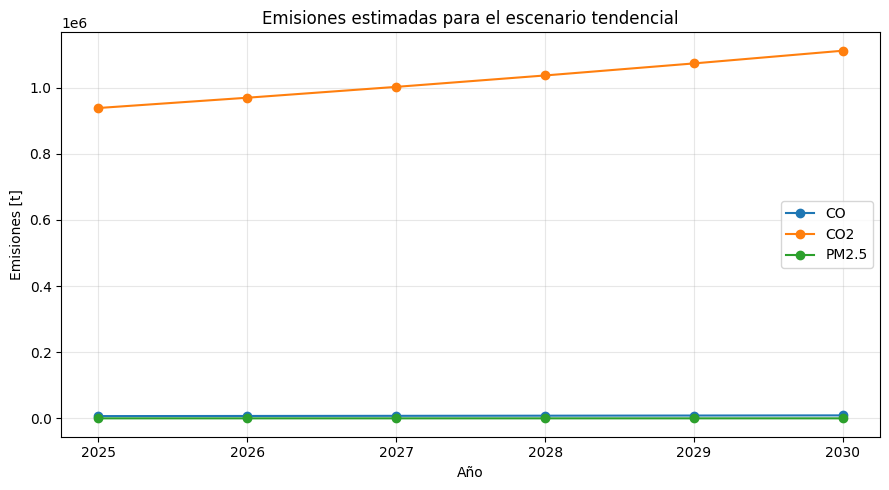

In [18]:
plt.figure(figsize=(9, 5))
for contaminante in ["CO", "CO2", "PM2.5"]:
    plt.plot(emisiones_tendencial["Año"], emisiones_tendencial[contaminante], marker="o", label=contaminante)
plt.xlabel("Año")
plt.ylabel("Emisiones [t]")
plt.title("Emisiones estimadas para el escenario tendencial")
plt.xticks(YEARS_PROJECTION)
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "Emisiones_Tendencial.png", dpi=PLOT_DPI, bbox_inches="tight")
plt.show()


## 9. Escenarios de penetración eléctrica

Los porcentajes de penetración se mantienen configurables y corresponden a los escenarios definidos en el notebook original. La penetración aumenta linealmente desde 0 % en 2025 hasta el objetivo definido para 2030.

In [19]:
EV_TARGETS = {
    "EV 0,01 %": 0.0001,
    "EV 0,05 %": 0.0005,
    "EV 0,1 %": 0.0010
}

def penetracion_ev(objetivo, year):
    return objetivo * (year - 2025) / 5

registros_escenarios = []

for escenario, objetivo in EV_TARGETS.items():
    for year in YEARS_PROJECTION:
        penetracion = penetracion_ev(objetivo, year)
        datos_year = parque_categoria[parque_categoria["Año"] == year]

        for _, fila in datos_year.iterrows():
            clase = fila["Vehículo"]
            cantidad = fila["Cantidad"]
            categoria_copert = mapeo_categoria[clase]
            factor = factores_emision.loc[categoria_copert]
            vehiculos_ev = cantidad * penetracion
            vehiculos_conv = cantidad - vehiculos_ev

            registros_escenarios.append({
                "Año": year,
                "Escenario": escenario,
                "Vehículo": clase,
                "Cantidad": cantidad,
                "Penetración EV (%)": penetracion * 100,
                "Vehículos EV": vehiculos_ev,
                "Vehículos convencionales": vehiculos_conv,
                "CO": vehiculos_conv * factor["CO"],
                "CO2": vehiculos_conv * factor["CO2"],
                "PM2.5": vehiculos_conv * factor["PM2.5"]
            })

escenarios_categoria = pd.DataFrame(registros_escenarios)
escenarios_df = escenarios_categoria.groupby(["Año", "Escenario"], as_index=False)[["CO", "CO2", "PM2.5"]].sum()

escenarios_categoria.to_csv(OUT / "Emisiones_Escenarios_por_Categoria.csv", index=False)
escenarios_df.to_csv(OUT / "Emisiones_Escenarios.csv", index=False)

display(escenarios_df)


,Año,Escenario,CO,CO2,PM2.5
0,2025,"EV 0,01 %",6857.136088,9.382311e+05,52.185319
1,2025,"EV 0,05 %",6857.136088,9.382311e+05,52.185319
2,2025,"EV 0,1 %",6857.136088,9.382311e+05,52.185319
3,2026,"EV 0,01 %",7233.732422,9.693097e+05,53.132656
4,2026,"EV 0,05 %",7233.153712,9.692322e+05,53.128405
5,2026,"EV 0,1 %",7232.430325,9.691353e+05,53.123092
6,2027,"EV 0,01 %",7633.800513,1.002065e+06,54.125713
7,2027,"EV 0,05 %",7632.579056,1.001905e+06,54.117052
8,2027,"EV 0,1 %",7631.052235,1.001704e+06,54.106227
9,2028,"EV 0,01 %",8058.733831,1.036550e+06,55.159616


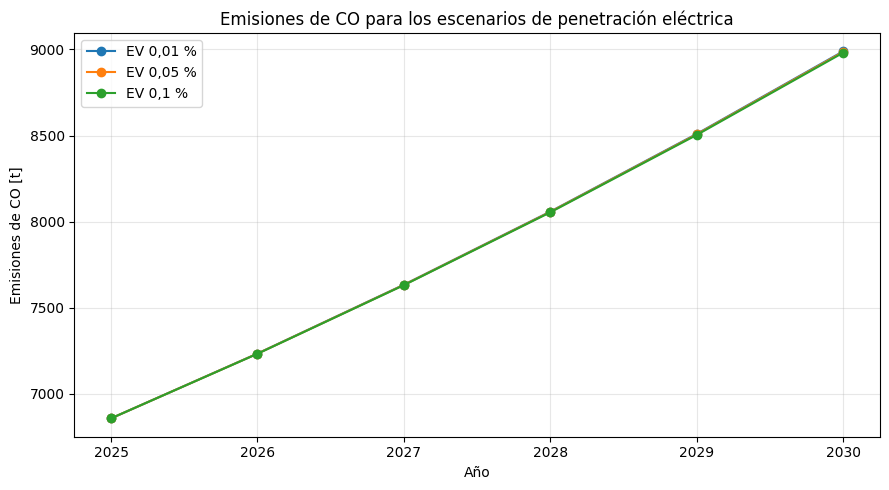

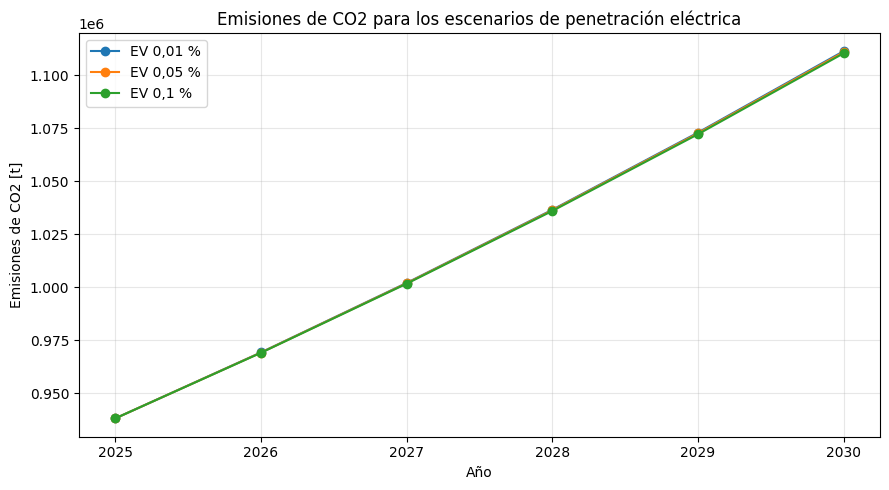

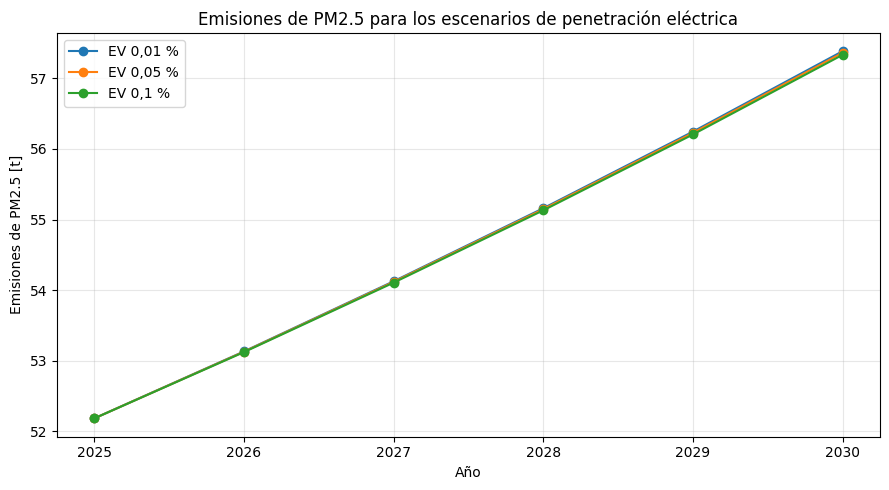

In [20]:
def grafica_escenarios(datos, contaminante, archivo):
    plt.figure(figsize=(9, 5))
    for escenario in datos["Escenario"].unique():
        subset = datos[datos["Escenario"] == escenario]
        plt.plot(subset["Año"], subset[contaminante], marker="o", label=escenario)
    plt.xlabel("Año")
    plt.ylabel(f"Emisiones de {contaminante} [t]")
    plt.title(f"Emisiones de {contaminante} para los escenarios de penetración eléctrica")
    plt.xticks(YEARS_PROJECTION)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT / archivo, dpi=PLOT_DPI, bbox_inches="tight")
    plt.show()

grafica_escenarios(escenarios_df, "CO", "Escenarios_CO.png")
grafica_escenarios(escenarios_df, "CO2", "Escenarios_CO2.png")
grafica_escenarios(escenarios_df, "PM2.5", "Escenarios_PM25.png")


## 10. Comparación y reducción de emisiones

In [21]:
tendencial_2030 = emisiones_tendencial.loc[emisiones_tendencial["Año"] == 2030].iloc[0]
tabla_general = []

for escenario, objetivo in EV_TARGETS.items():
    escenario_2030 = escenarios_df[(escenarios_df["Escenario"] == escenario) & (escenarios_df["Año"] == 2030)].iloc[0]

    for contaminante in ["CO", "CO2", "PM2.5"]:
        base_2025 = linea_base.loc[2025, contaminante]
        tend_2030 = tendencial_2030[contaminante]
        esc_2030 = escenario_2030[contaminante]
        reduccion = tend_2030 - esc_2030

        tabla_general.append([
            escenario,
            objetivo * 100,
            contaminante,
            base_2025,
            tend_2030,
            esc_2030,
            esc_2030 - base_2025,
            (esc_2030 - base_2025) / base_2025 * 100,
            reduccion,
            reduccion / tend_2030 * 100
        ])

tabla_general = pd.DataFrame(tabla_general, columns=[
    "Escenario", "Penetración EV 2030 (%)", "Contaminante",
    "Línea base 2025 (t)", "Tendencial 2030 (t)", "Escenario 2030 (t)",
    "Variación 2025-2030 (t)", "Variación 2025-2030 (%)",
    "Reducción vs tendencial 2030 (t)", "Reducción vs tendencial 2030 (%)"
])

tabla_general.to_csv(OUT / "Tabla_General_Emisiones.csv", index=False)
display(tabla_general)


,Escenario,Penetración EV 2030 (%),Contaminante,Línea base 2025 (t),Tendencial 2030 (t),Escenario 2030 (t),Variación 2025-2030 (t),Variación 2025-2030 (%),Reducción vs tendencial 2030 (t),Reducción vs tendencial 2030 (%)
0,"EV 0,01 %",0.01,CO,6856.068452,8.990873e+03,8.989974e+03,2133.905578,31.124333,0.899087,0.01
1,"EV 0,01 %",0.01,CO2,937841.878024,1.111409e+06,1.111298e+06,173456.025937,18.495231,111.140904,0.01
2,"EV 0,01 %",0.01,PM2.5,52.182814,5.738829e+01,5.738256e+01,5.199741,9.964471,0.005739,0.01
3,"EV 0,05 %",0.05,CO,6856.068452,8.990873e+03,8.986378e+03,2130.309228,31.071878,4.495437,0.05
4,"EV 0,05 %",0.05,CO2,937841.878024,1.111409e+06,1.110853e+06,173011.462319,18.447829,555.704522,0.05
5,"EV 0,05 %",0.05,PM2.5,52.182814,5.738829e+01,5.735960e+01,5.176786,9.920481,0.028694,0.05
6,"EV 0,1 %",0.10,CO,6856.068452,8.990873e+03,8.981882e+03,2125.813792,31.006309,8.990873,0.10
7,"EV 0,1 %",0.10,CO2,937841.878024,1.111409e+06,1.110298e+06,172455.757796,18.388575,1111.409045,0.10
8,"EV 0,1 %",0.10,PM2.5,52.182814,5.738829e+01,5.733091e+01,5.148092,9.865493,0.057388,0.10


In [22]:
reduccion_anual = []

for escenario, objetivo in EV_TARGETS.items():
    for year in YEARS_PROJECTION:
        tend = emisiones_tendencial[emisiones_tendencial["Año"] == year].iloc[0]
        esc = escenarios_df[(escenarios_df["Año"] == year) & (escenarios_df["Escenario"] == escenario)].iloc[0]

        registro = {
            "Año": year,
            "Escenario": escenario,
            "Penetración EV (%)": penetracion_ev(objetivo, year) * 100
        }

        for contaminante in ["CO", "CO2", "PM2.5"]:
            evitado = tend[contaminante] - esc[contaminante]
            registro[f"{contaminante} tendencial (t)"] = tend[contaminante]
            registro[f"{contaminante} escenario (t)"] = esc[contaminante]
            registro[f"{contaminante} evitado (t)"] = evitado
            registro[f"Reducción {contaminante} (%)"] = evitado / tend[contaminante] * 100

        reduccion_anual.append(registro)

reduccion_anual = pd.DataFrame(reduccion_anual)
reduccion_anual.to_csv(OUT / "Tabla_Reduccion_por_Año_y_Escenario.csv", index=False)
display(reduccion_anual)


,Año,Escenario,Penetración EV (%),CO tendencial (t),CO escenario (t),CO evitado (t),Reducción CO (%),CO2 tendencial (t),CO2 escenario (t),CO2 evitado (t),Reducción CO2 (%),PM2.5 tendencial (t),PM2.5 escenario (t),PM2.5 evitado (t),Reducción PM2.5 (%)
0,2025,"EV 0,01 %",0.000,6857.136088,6857.136088,0.000000,0.000,9.382311e+05,9.382311e+05,0.000000,0.000,52.185319,52.185319,0.000000,0.000
1,2026,"EV 0,01 %",0.002,7233.877100,7233.732422,0.144678,0.002,9.693291e+05,9.693097e+05,19.386583,0.002,53.133719,53.132656,0.001063,0.002
2,2027,"EV 0,01 %",0.004,7634.105877,7633.800513,0.305364,0.004,1.002105e+06,1.002065e+06,40.084198,0.004,54.127878,54.125713,0.002165,0.004
3,2028,"EV 0,01 %",0.006,8059.217384,8058.733831,0.483553,0.006,1.036612e+06,1.036550e+06,62.196723,0.006,55.162926,55.159616,0.003310,0.006
4,2029,"EV 0,01 %",0.008,8510.923365,8510.242491,0.680874,0.008,1.073013e+06,1.072927e+06,85.841037,0.008,56.248839,56.244339,0.004500,0.008
5,2030,"EV 0,01 %",0.010,8990.873116,8989.974029,0.899087,0.010,1.111409e+06,1.111298e+06,111.140904,0.010,57.388295,57.382556,0.005739,0.010
6,2025,"EV 0,05 %",0.000,6857.136088,6857.136088,0.000000,0.000,9.382311e+05,9.382311e+05,0.000000,0.000,52.185319,52.185319,0.000000,0.000
7,2026,"EV 0,05 %",0.010,7233.877100,7233.153712,0.723388,0.010,9.693291e+05,9.692322e+05,96.932913,0.010,53.133719,53.128405,0.005313,0.010
8,2027,"EV 0,05 %",0.020,7634.105877,7632.579056,1.526821,0.020,1.002105e+06,1.001905e+06,200.420989,0.020,54.127878,54.117052,0.010826,0.020
9,2028,"EV 0,05 %",0.030,8059.217384,8056.799619,2.417765,0.030,1.036612e+06,1.036301e+06,310.983615,0.030,55.162926,55.146377,0.016549,0.030


In [23]:
reducciones_categoria = []

for escenario, objetivo in EV_TARGETS.items():
    for year in YEARS_PROJECTION:
        penetracion = penetracion_ev(objetivo, year)
        parque_year = parque_categoria[parque_categoria["Año"] == year].copy()
        total_parque = parque_year["Cantidad"].sum()
        tend_year = emisiones_categoria_tendencial[emisiones_categoria_tendencial["Año"] == year]

        for _, fila in parque_year.iterrows():
            clase = fila["Vehículo"]
            cantidad = fila["Cantidad"]
            tend = tend_year[tend_year["Vehículo"] == clase].iloc[0]

            registro = {
                "Año": year,
                "Escenario": escenario,
                "Vehículo": clase,
                "Cantidad": cantidad,
                "Participación parque (%)": cantidad / total_parque * 100,
                "Penetración EV (%)": penetracion * 100,
                "Vehículos EV": cantidad * penetracion,
                "Vehículos convencionales": cantidad * (1 - penetracion)
            }

            for contaminante in ["CO", "CO2", "PM2.5"]:
                registro[f"{contaminante} tendencial (t)"] = tend[contaminante]
                registro[f"{contaminante} evitado (t)"] = tend[contaminante] * penetracion
                registro[f"{contaminante} escenario (t)"] = tend[contaminante] * (1 - penetracion)

            reducciones_categoria.append(registro)

reducciones_categoria = pd.DataFrame(reducciones_categoria)
reducciones_categoria.to_csv(OUT / "Analisis_Reduccion_por_Categoria.csv", index=False)

tabla_categoria_2030 = reducciones_categoria[reducciones_categoria["Año"] == 2030].copy()
tabla_categoria_2030 = tabla_categoria_2030[
    ["Escenario", "Vehículo", "Cantidad", "Participación parque (%)",
     "Penetración EV (%)", "Vehículos EV",
     "CO evitado (t)", "CO2 evitado (t)", "PM2.5 evitado (t)"]
].sort_values(["Escenario", "Vehículo"])

tabla_categoria_2030.to_csv(OUT / "Tabla_Categoria_2030.csv", index=False)
display(tabla_categoria_2030)


,Escenario,Vehículo,Cantidad,Participación parque (%),Penetración EV (%),Vehículos EV,CO evitado (t),CO2 evitado (t),PM2.5 evitado (t)
30,"EV 0,01 %",AUTOMÓVIL,190266,16.060878,0.01,19.0266,0.075797,27.630767,0.000178
31,"EV 0,01 %",BUS,4344,0.366689,0.01,0.4344,0.018575,10.589069,0.001586
32,"EV 0,01 %",BUSETA,3629,0.306334,0.01,0.3629,0.015518,8.846163,0.001325
33,"EV 0,01 %",CAMIONETA,111015,9.371083,0.01,11.1015,0.044225,16.121796,0.000104
34,"EV 0,01 %",MICRO BUS,3772,0.318405,0.01,0.3772,0.016129,9.194744,0.001377
35,"EV 0,01 %",MOTOCICLETA,871629,73.576611,0.01,87.1629,0.728844,38.758365,0.001169
66,"EV 0,05 %",AUTOMÓVIL,190266,16.060878,0.05,95.1330,0.378983,138.153834,0.000889
67,"EV 0,05 %",BUS,4344,0.366689,0.05,2.1720,0.092874,52.945346,0.007930
68,"EV 0,05 %",BUSETA,3629,0.306334,0.05,1.8145,0.077588,44.230815,0.006625
69,"EV 0,05 %",CAMIONETA,111015,9.371083,0.05,55.5075,0.221126,80.608979,0.000519


## 11. Validaciones finales

In [24]:
print("VALIDACIÓN DEL FLUJO")
print(f"Categorías objetivo: {len(TARGET_CLASSES)}")
print(f"Años históricos disponibles: {YEARS_HIST[0]}–{YEARS_HIST[-1]}")
print(f"Años proyectados: {YEARS_PROJECTION[0]}–{YEARS_PROJECTION[-1]}")
print(f"Filas de proyeccion: {len(proyeccion):,}")
print(f"Total parque objetivo 2025: {parque_anual.loc[parque_anual['Año'] == 2025, 'Cantidad'].iloc[0]:,.0f}")
print(f"Total parque objetivo 2030: {parque_anual.loc[parque_anual['Año'] == 2030, 'Cantidad'].iloc[0]:,.0f}")

assert set(proyeccion["Vehículo"].unique()) == set(TARGET_CLASSES)
assert set(proyeccion["Año"].unique()) == set(YEARS_PROJECTION)
assert proyeccion["Cantidad"].ge(0).all()
assert escenarios_df["Año"].between(2025, 2030).all()

print("Todas las validaciones básicas fueron superadas.")


VALIDACIÓN DEL FLUJO
Categorías objetivo: 6
Años históricos disponibles: 2018–2025
Años proyectados: 2025–2030
Filas de proyeccion: 102
Total parque objetivo 2025: 910,513
Total parque objetivo 2030: 1,184,655
Todas las validaciones básicas fueron superadas.
